In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df = pd.read_csv("AmesHousing.csv")

In [118]:
df.shape

(2930, 82)

In [119]:
df.head(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [121]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [122]:
df.isnull().sum().sort_values(ascending=False)

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159


In [123]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Values,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Yr Blt,159,5.426621
Garage Cond,159,5.426621


In [124]:
missing_df.head(15)

,Missing Values,Missing Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Yr Blt,159,5.426621
Garage Cond,159,5.426621


In [125]:
df[df['Lot Frontage'].isnull()]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
11,12,527165230,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal,185000
14,15,527182190,120,RL,NaN,6820,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,212000
22,23,527368020,60,FV,NaN,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,216000
23,24,527402200,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
24,25,527402250,20,RL,NaN,12537,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,149900
55,56,528240070,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,216500
57,58,528250100,80,RL,NaN,7750,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,180000
58,59,528292020,60,RL,NaN,9505,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,222500
74,75,531380080,60,RL,NaN,8880,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,205000
79,80,531452180,60,RL,NaN,9453,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2010,WD,Normal,194500


In [126]:
df['Lot Frontage'].describe()

,Lot Frontage
count,2440.000000
mean,69.224590
std,23.365335
min,21.000000
25%,58.000000
50%,68.000000
75%,80.000000
max,313.000000


In [127]:
df["Lot Frontage"] = df["Lot Frontage"].fillna(df["Lot Frontage"].median())

In [128]:
df["Lot Frontage"].isnull().sum()

np.int64(0)

In [129]:
df["Fireplace Qu"] = df["Fireplace Qu"].fillna("No Fireplace")

In [130]:
df["Fireplace Qu"].isnull().sum()

np.int64(0)

In [131]:
columns_to_drop = [
    "Pool QC",
    "Misc Feature",
    "Alley",
    "Fence"
]

df.drop(columns=columns_to_drop, inplace=True)

In [132]:
df.shape

(2930, 78)

In [133]:
df['Garage Finish'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: Garage Finish
Non-Null Count  Dtype 
--------------  ----- 
2771 non-null   object
dtypes: object(1)
memory usage: 23.0+ KB


In [134]:
garage_cat_cols = [
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond"
]

for col in garage_cat_cols:
    df[col] = df[col].fillna("No Garage")

In [135]:
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(0)

In [136]:
df[garage_cat_cols + ["Garage Yr Blt"]].isnull().sum()

,0
Garage Type,0
Garage Finish,0
Garage Qual,0
Garage Cond,0
Garage Yr Blt,0


In [137]:
df["Mas Vnr Type"].isnull().sum()

np.int64(1775)

In [138]:
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")

In [139]:
df["Mas Vnr Type"].value_counts(dropna=False)

,count
Mas Vnr Type,
None,1775
BrkFace,880
Stone,249
BrkCmn,25
CBlock,1


In [140]:
df['Bsmt Exposure'].value_counts()

,count
Bsmt Exposure,
No,1906
Av,418
Gd,284
Mn,239


In [141]:
bsmt_cat_cols = [
     'Bsmt Qual' ,
   'Bsmt Cond',
   'Bsmt Exposure',
   'BsmtFin Type 1' ,

   'BsmtFin Type 2',

]

for col in bsmt_cat_cols:
    df[col] = df[col].fillna("No Basement")

In [142]:
bsmt_num_cols = [
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath"
]

for col in bsmt_num_cols:
    df[col] = df[col].fillna(0)

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 78 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [144]:
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)

In [145]:
garage_num_cols = [
    "Garage Cars",
    "Garage Area"
]

for col in garage_num_cols:
    df[col] = df[col].fillna(0)

In [146]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Electrical,1
Order,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
PID,0
Street,0
Lot Shape,0
Land Contour,0
Utilities,0


In [147]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [148]:
df.duplicated().sum()

np.int64(0)

In [149]:
cols_to_drop = ["Order", "PID"]

df.drop(columns=cols_to_drop, inplace=True)

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2930 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Lot Shape        2930 non-null   object 
 6   Land Contour     2930 non-null   object 
 7   Utilities        2930 non-null   object 
 8   Lot Config       2930 non-null   object 
 9   Land Slope       2930 non-null   object 
 10  Neighborhood     2930 non-null   object 
 11  Condition 1      2930 non-null   object 
 12  Condition 2      2930 non-null   object 
 13  Bldg Type        2930 non-null   object 
 14  House Style      2930 non-null   object 
 15  Overall Qual     2930 non-null   int64  
 16  Overall Cond     2930 non-null   int64  
 17  Year Built    

In [151]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

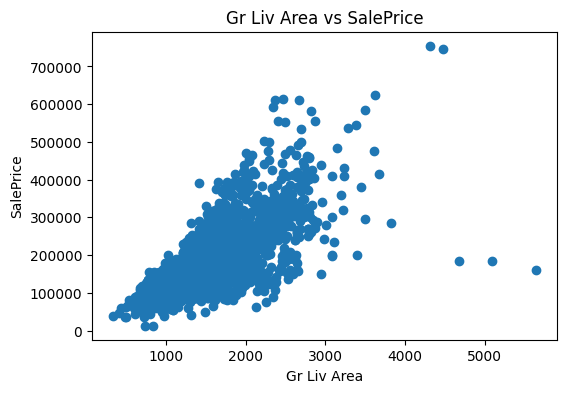

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["Gr Liv Area"], df["SalePrice"])
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.title("Gr Liv Area vs SalePrice")
plt.show()

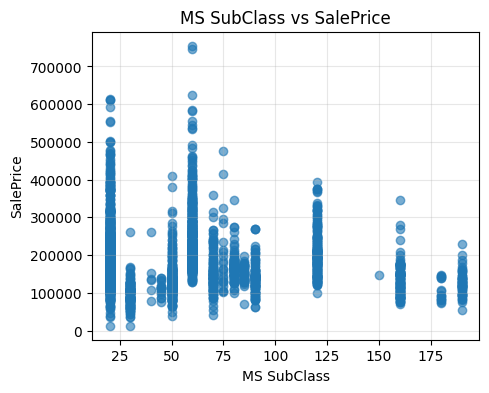

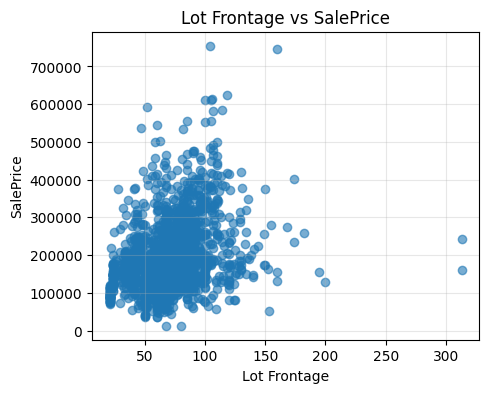

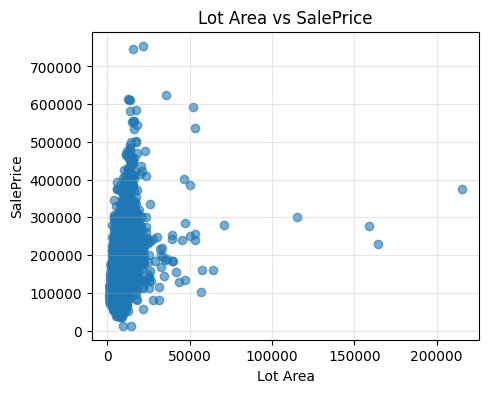

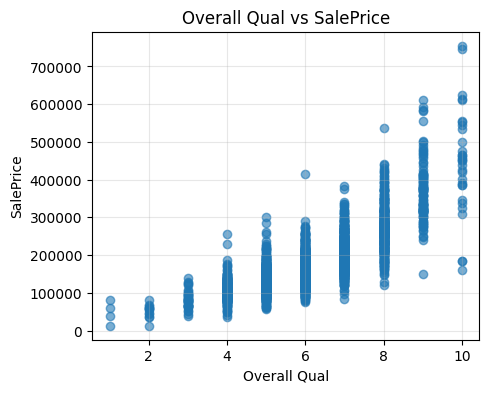

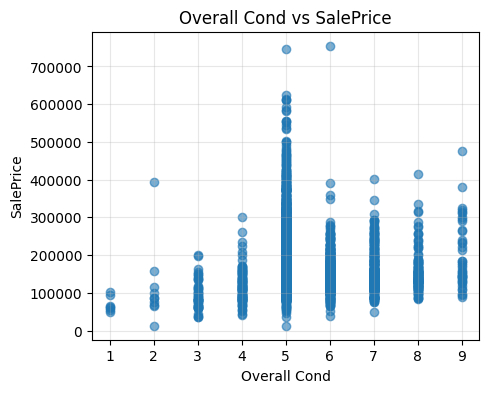

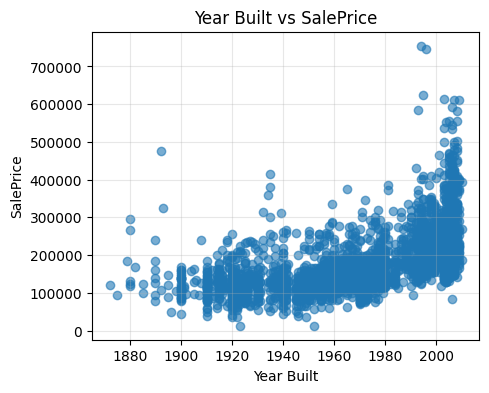

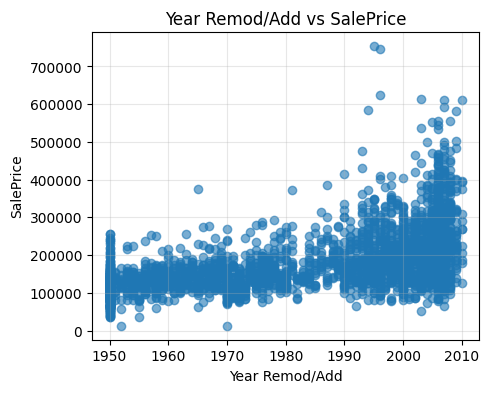

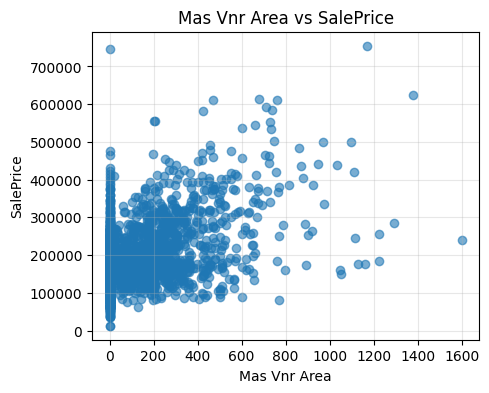

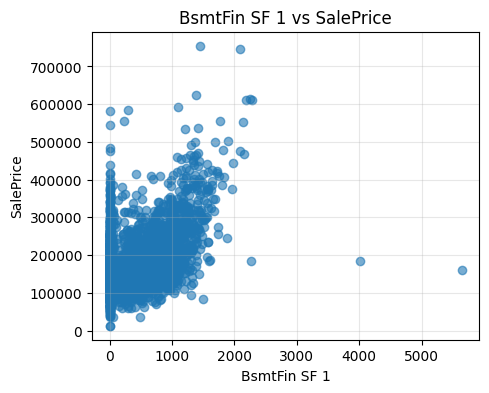

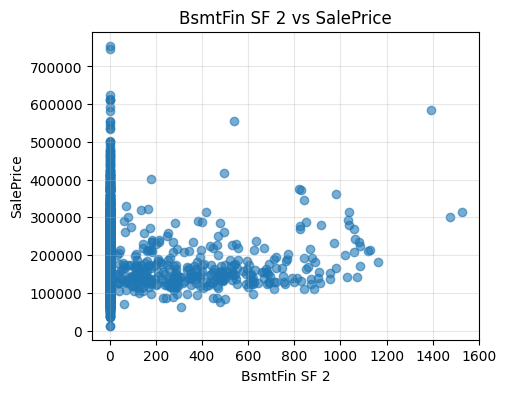

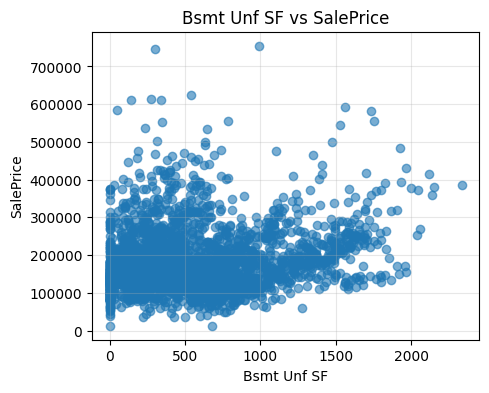

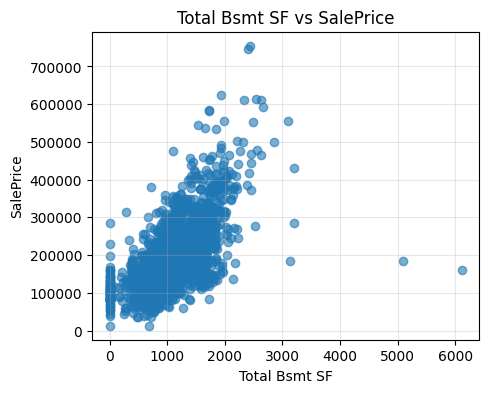

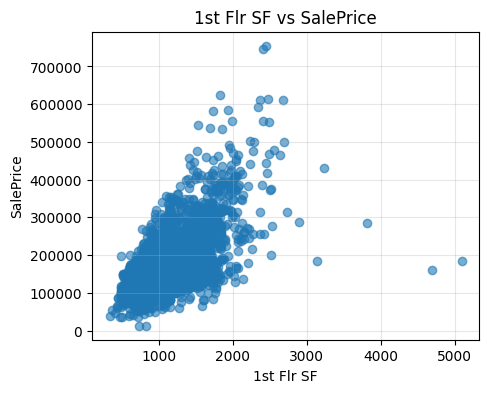

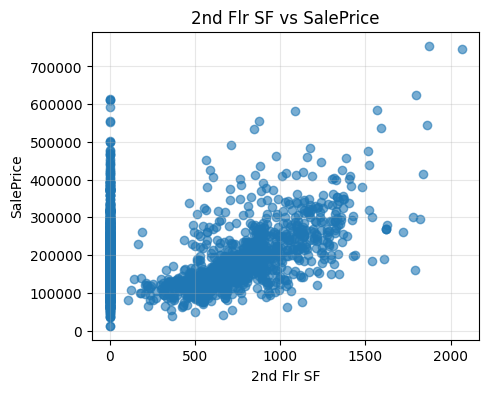

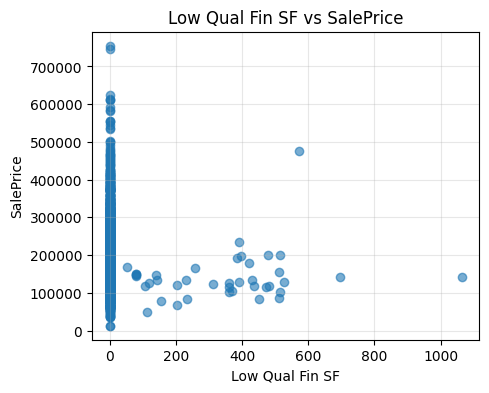

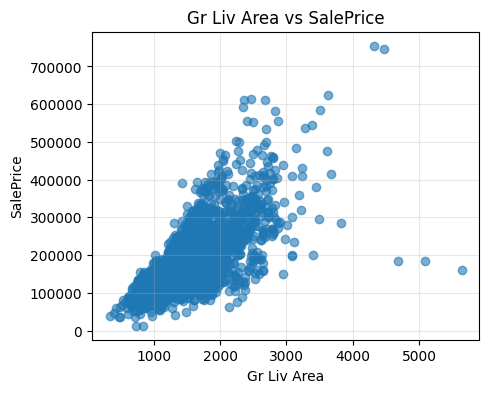

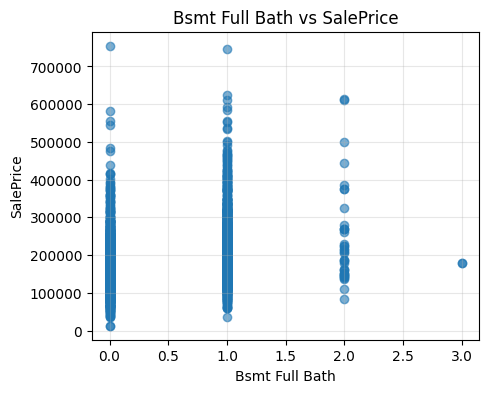

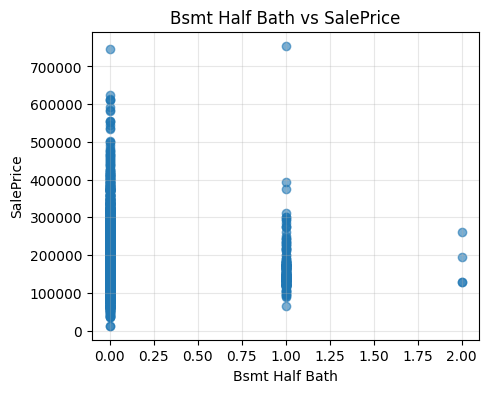

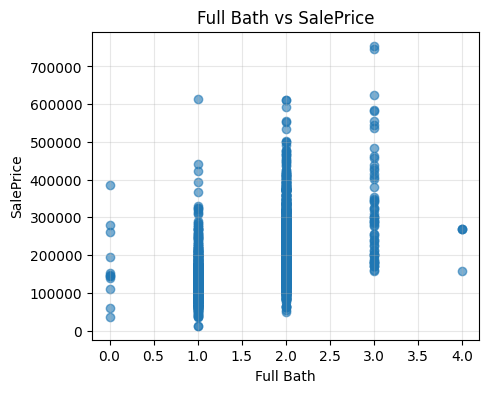

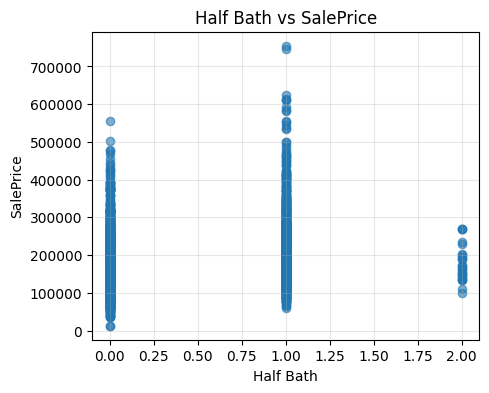

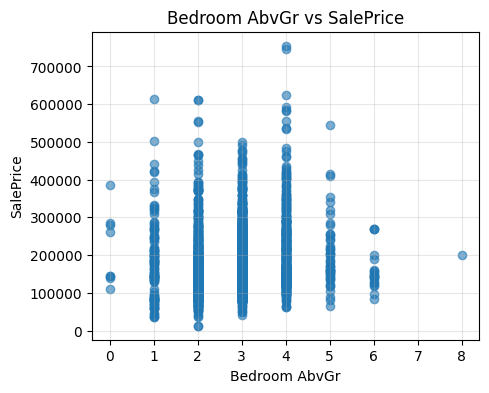

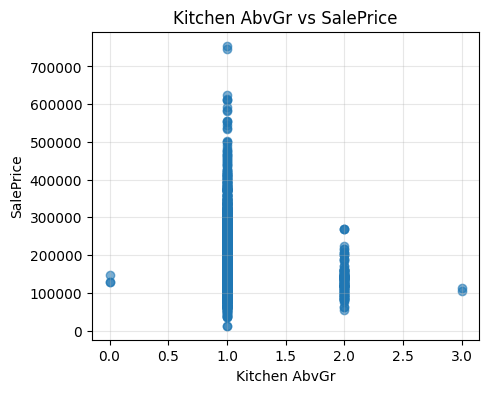

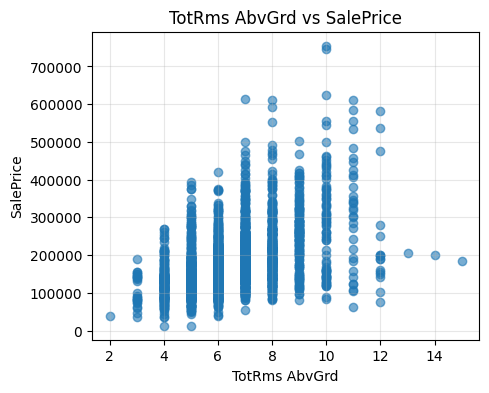

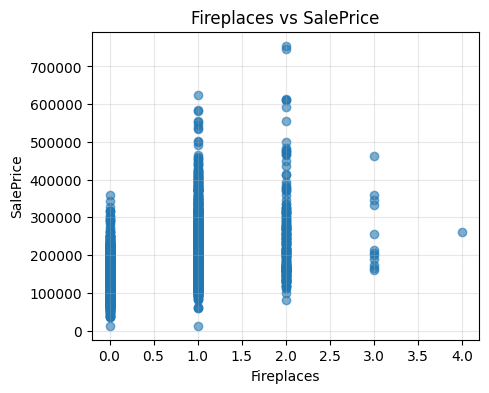

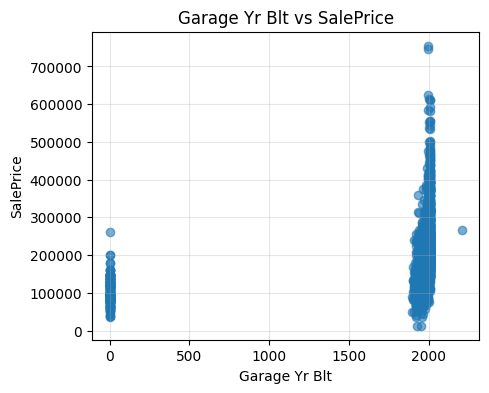

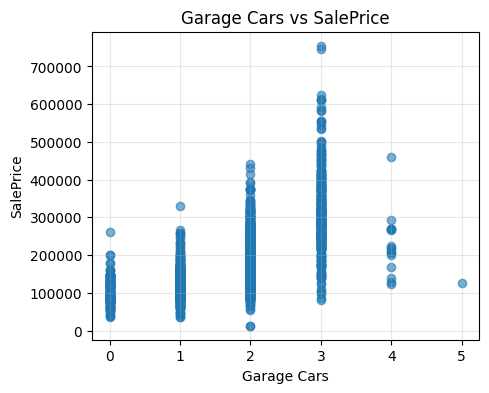

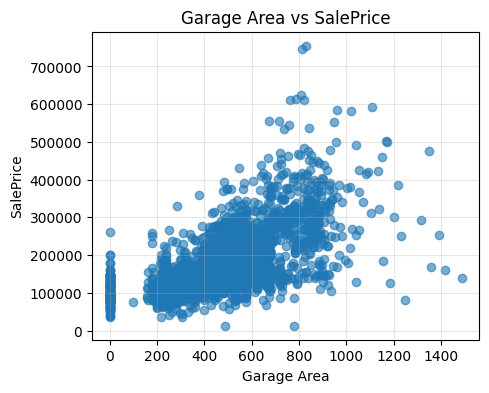

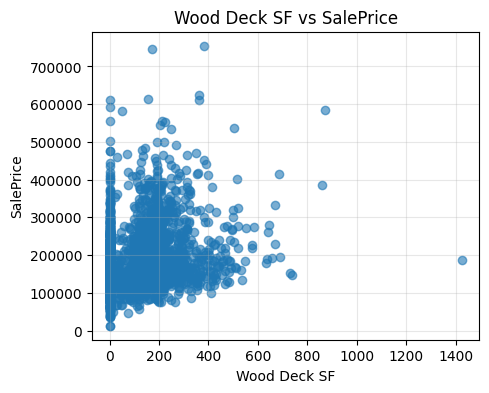

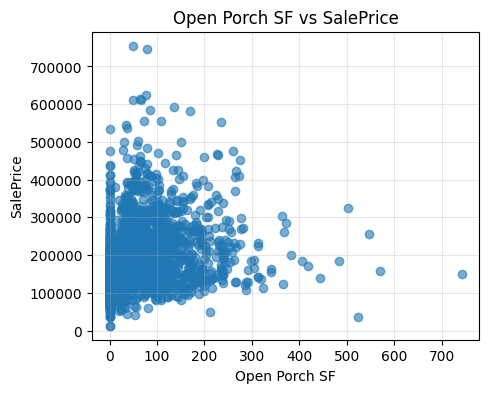

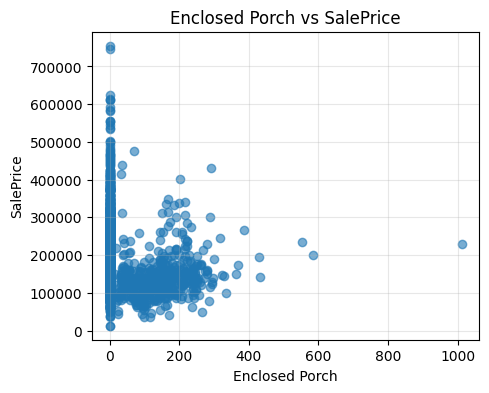

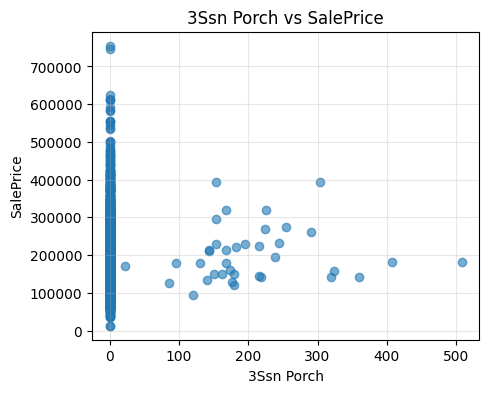

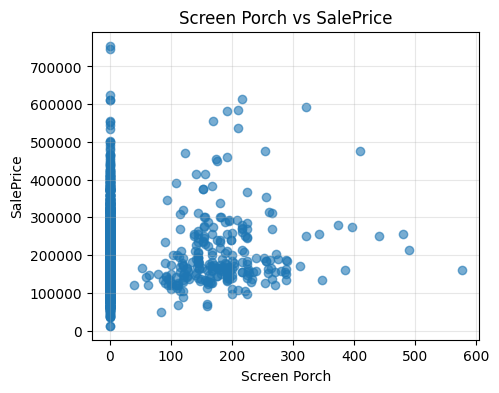

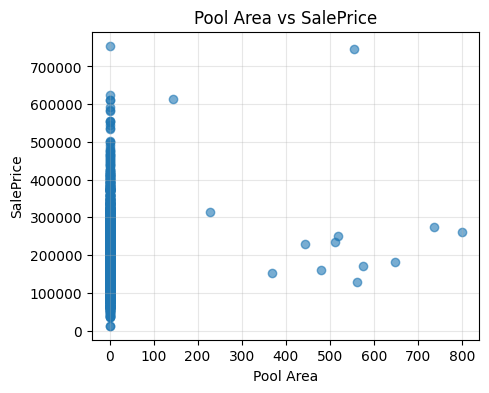

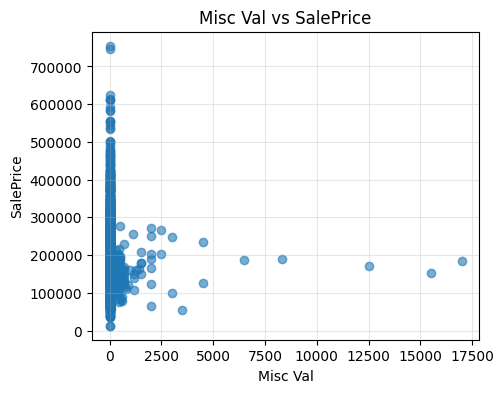

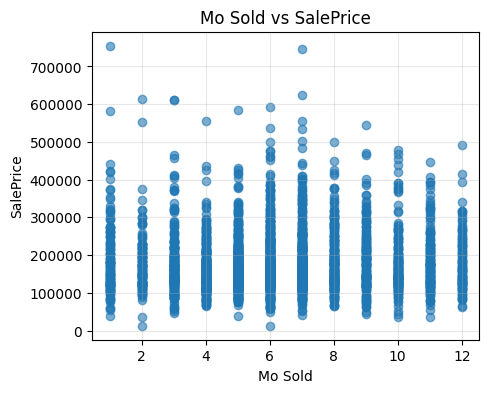

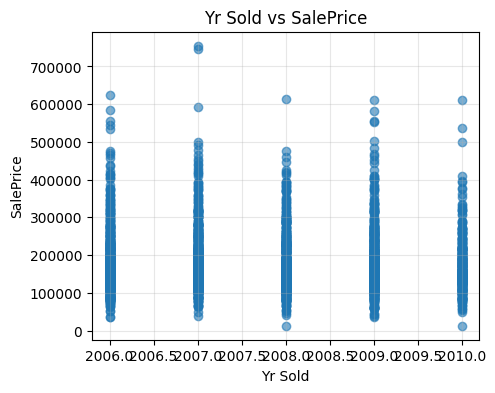

In [153]:
import matplotlib.pyplot as plt

# Numerical columns except target
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop("SalePrice")

for col in num_cols:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col], df["SalePrice"], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.title(f"{col} vs SalePrice")
    plt.grid(alpha=0.3)
    plt.show()

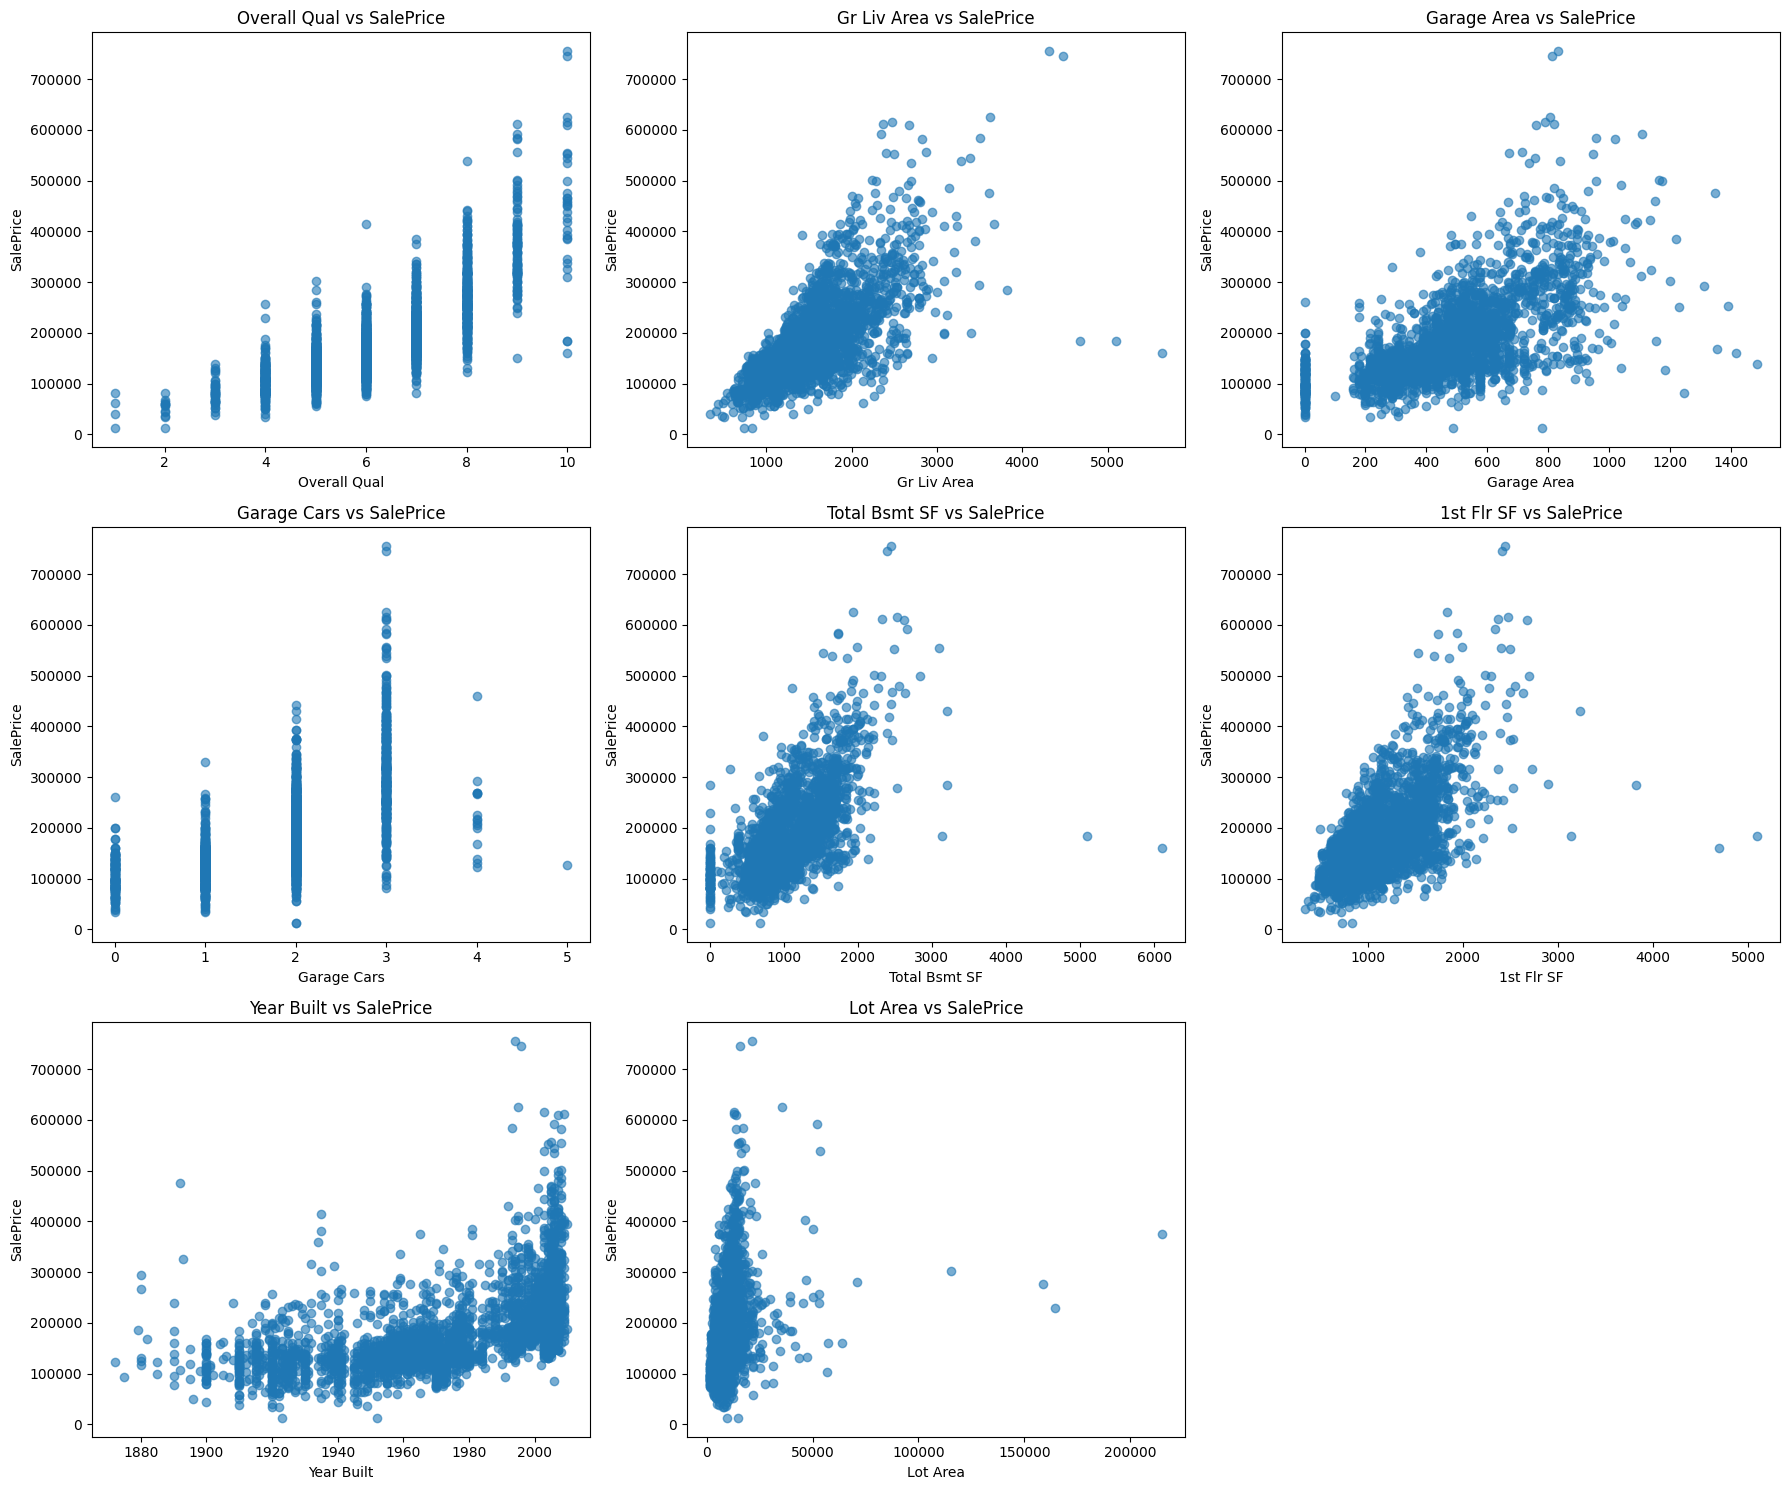

In [154]:
import matplotlib.pyplot as plt

important_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Area",
    "Garage Cars",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Lot Area"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(important_features):
    axes[i].scatter(df[col], df["SalePrice"], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")
    axes[i].set_title(f"{col} vs SalePrice")

# Remove the extra subplot
for j in range(len(important_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [155]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": count
    })

import pandas as pd

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("Outliers", ascending=False)

,Feature,Outliers
29,Enclosed Porch,459
9,BsmtFin SF 2,351
1,Lot Frontage,261
31,Screen Porch,256
4,Overall Cond,252
0,MS SubClass,208
7,Mas Vnr Area,203
17,Bsmt Half Bath,175
24,Garage Yr Blt,160
28,Open Porch SF,159


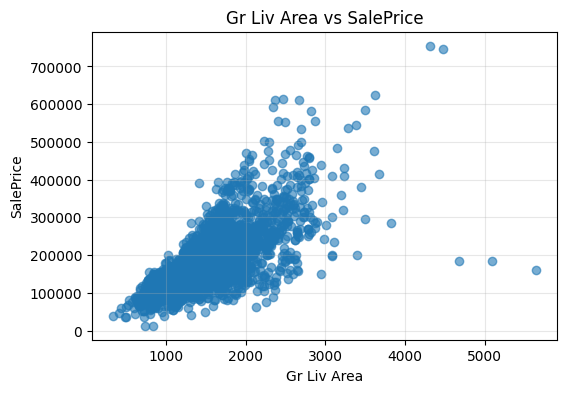

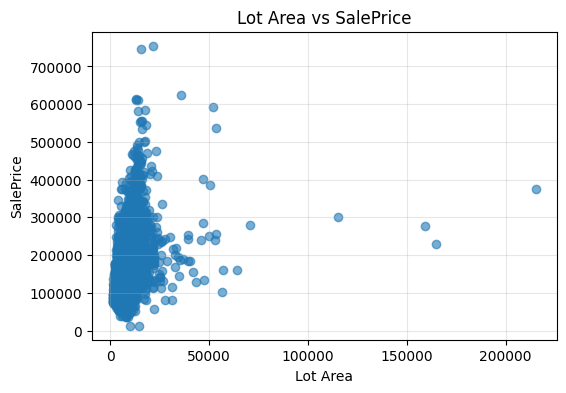

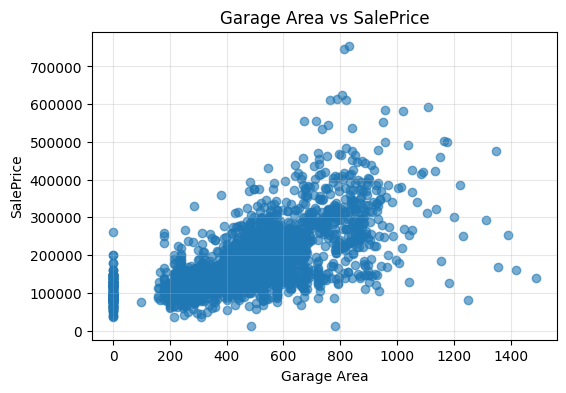

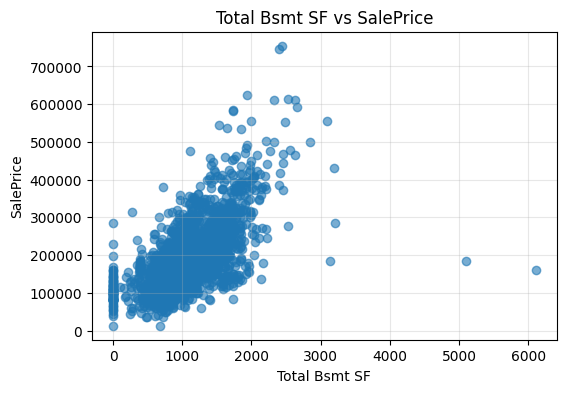

In [156]:
import matplotlib.pyplot as plt

important_features = [
    "Gr Liv Area",
    "Lot Area",
    "Garage Area",
    "Total Bsmt SF"
]

for col in important_features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["SalePrice"], alpha=0.6)
    plt.title(f"{col} vs SalePrice")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.grid(alpha=0.3)
    plt.show()

In [157]:
df = df.drop(df[(df["Gr Liv Area"] > 4000) &
                (df["SalePrice"] < 300000)].index)

In [166]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [168]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols)
print("Total categorical columns:", len(cat_cols))

Index([], dtype='object')
Total categorical columns: 0


In [169]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2927 entries, 0 to 2929
Columns: 260 entries, MS SubClass to Sale Condition_Partial
dtypes: float64(11), int64(249)
memory usage: 5.8 MB


In [171]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [172]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("SalePrice", axis=1)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


KeyboardInterrupt: 

In [173]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [175]:
vif = pd.DataFrame()

vif["Feature"] = X_train.columns
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False)

vif

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
185,BsmtFin Type 1_No Basement,inf
170,Bsmt Qual_No Basement,inf
176,Bsmt Cond_Po,inf
206,Electrical_Mix,inf
175,Bsmt Cond_No Basement,inf
15,Gr Liv Area,inf
229,Garage Type_No Garage,inf
230,Garage Finish_No Garage,inf
235,Garage Qual_No Garage,inf
240,Garage Cond_No Garage,inf


In [176]:
cols_to_drop = [
    # Basement decomposition
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",

    # Floor decomposition
    "1st Flr SF",
    "2nd Flr SF",
    "Low Qual Fin SF",

    # Duplicate "No Basement"
    "BsmtFin Type 1_No Basement",
    "Bsmt Cond_No Basement",

    # Duplicate "No Garage"
    "Garage Type_No Garage",
    "Garage Finish_No Garage",
    "Garage Qual_No Garage",

    # Highly correlated year
    "Garage Yr Blt"
]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [177]:
cols_to_drop = [
    "Electrical_Mix",
    "Exterior 1st_PreCast",
    "Exterior 2nd_PreCast",
    "Bsmt Cond_Po"
]

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [178]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame({
    "Feature": X_train.columns,
    "VIF": [variance_inflation_factor(X_train.values, i)
            for i in range(X_train.shape[1])]
}).sort_values("VIF", ascending=False)

vif.head(20)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
28,Yr Sold,90243.806820
5,Year Built,57952.376251
6,Year Remod/Add,30530.193418
33,MS Zoning_RL,3346.584707
182,Heating_GasA,2650.741362
221,Garage Qual_TA,1716.783076
226,Garage Cond_TA,1590.494571
86,Condition 2_Norm,889.048367
34,MS Zoning_RM,682.027191
166,Bsmt Cond_TA,656.659734


In [180]:
X_train = X_train.drop(columns=["Yr Sold"])
X_test = X_test.drop(columns=["Yr Sold"])

In [181]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [182]:
y_pred = model.predict(X_test)

In [183]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 15446.91763724243
MSE : 556233564.2629341
RMSE: 23584.604390638695
R² Score: 0.9309834868988441


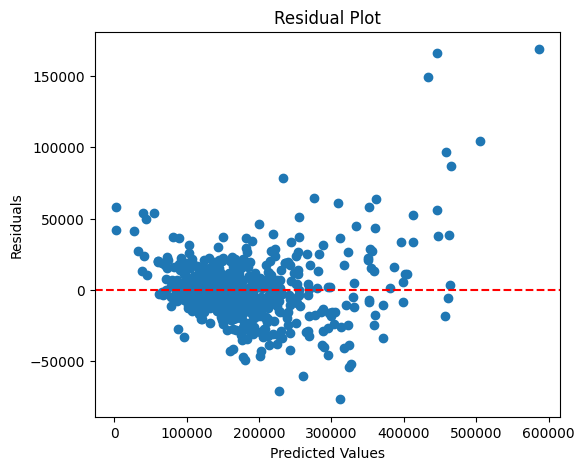

In [184]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

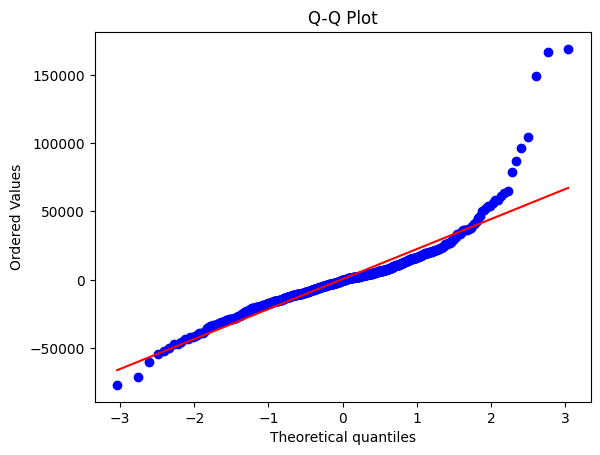

In [185]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()